In [1]:
# importing of libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# reading dataset
df1 = pd.read_excel("Bank_Churn_Messy.xlsx", sheet_name = 0)
df2 = pd.read_excel("Bank_Churn_Messy.xlsx", sheet_name = 1)
# merging both dataset to one
df = pd.merge(df1, df2, on = ["CustomerId", "Tenure"], how = "inner")
df.head(20)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0
6,15574012,Chu,645,Spain,Male,44.0,8,€149756.71,€113755.78,2,No,No,1
7,15592531,Bartlett,822,France,Male,50.0,7,€10062.8,€0.0,2,Yes,Yes,0
8,15656148,Obinna,376,Germany,Female,29.0,4,€119346.88,€115046.74,4,No,No,1
9,15792365,He,501,French,Male,44.0,4,€74940.5,€142051.07,2,Yes,Yes,0


In [3]:
# inspecting the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure           10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  IsActiveMember   10004 non-null  object 
 12  Exited           10004 non-null  int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 1016.2+ KB


In [4]:
# checking for missing values
df.isnull().sum()

CustomerId         0
Surname            3
CreditScore        0
Geography          0
Gender             0
Age                3
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [5]:
# checking for duplicates values
print(df.duplicated().sum())

4


In [6]:
# handling of missing values
df.dropna(inplace=True)
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [7]:
# handling duplicates values
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [8]:
df["Geography"].unique()

array(['FRA', 'Spain', 'French', 'France', 'Germany'], dtype=object)

In [9]:
df["Geography"].replace({
    "FRA": "France",
    "French": "France"
}, inplace=True)

df["Geography"].unique()

C:\Users\USER\AppData\Local\Temp\ipykernel_13228\3315793429.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Geography"].replace({


array(['France', 'Spain', 'Germany'], dtype=object)

In [10]:
def clean_currency(x):
    if isinstance(x, str):
        return float(x.replace("€", ""))
    return x
df["EstimatedSalary"] = df["EstimatedSalary"].apply(clean_currency)
df["Balance"] = df["Balance"].apply(clean_currency)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


In [11]:
# converting excited column with (1- yes, 0 - no)
# df["Exited"] = df["Exited"].replace({
#     0:"No",
#     1: "Yes"
# })
# df.head()

In [12]:
# filtering customer with high credit score 
high_customer_credit_score = df[df["CreditScore"] >= 700]
high_customer_credit_score 

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0
7,15592531,Bartlett,822,France,Male,50.0,7,10062.80,0.00,2,Yes,Yes,0
20,15568982,Hao,726,France,Female,24.0,6,54724.03,0.00,2,Yes,Yes,0
21,15577657,McDonald,732,France,Male,41.0,8,170886.17,0.00,2,Yes,Yes,0
25,15625047,Yen,846,France,Female,38.0,5,187616.16,0.00,1,Yes,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15719294,Wood,800,France,Female,29.0,2,167773.55,0.00,2,No,No,0
9996,15606229,Obijiaku,771,France,Male,39.0,5,96270.64,0.00,2,No,No,0
9998,15584532,Liu,709,France,Female,36.0,7,42085.58,0.00,1,Yes,Yes,1
9999,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52,75075.31,2,No,No,1


In [13]:
# finding active member in germany
active_member_in_germany = df[(df["Geography"] == "Germany") & (df["IsActiveMember"] == "Yes")]
active_member_in_germany


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
16,15643966,Goforth,616,Germany,Male,45.0,3,64327.26,143129.41,2,Yes,Yes,0
27,15736816,Young,756,Germany,Male,36.0,2,170041.95,136815.64,1,Yes,Yes,0
40,15585768,Cameron,582,Germany,Male,41.0,6,178074.04,70349.48,2,Yes,Yes,0
46,15754849,Tyler,776,Germany,Female,32.0,4,126517.46,109421.13,2,Yes,Yes,0
47,15602280,Martin,829,Germany,Female,27.0,9,119708.21,112045.67,1,Yes,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9951,15638494,Salinas,625,Germany,Female,39.0,10,96444.88,129845.26,1,Yes,Yes,0
9961,15681026,Lucciano,795,Germany,Female,33.0,9,120853.83,104552.72,1,Yes,Yes,1
9982,15672754,Burbidge,498,Germany,Male,42.0,3,53445.17,152039.70,1,Yes,Yes,1
9985,15696175,Echezonachukwu,602,Germany,Male,35.0,7,51695.41,90602.42,2,Yes,Yes,0


In [14]:
df.groupby("Geography")["IsActiveMember"].value_counts()

Geography  IsActiveMember
France     Yes               2590
           No                2423
Germany    No                1261
           Yes               1247
Spain      Yes               1312
           No                1164
Name: count, dtype: int64

In [15]:
churned_customer = df[df["Exited"] == "Yes"]
churned_customer

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited


In [16]:
# creating a new dataframe 
np.random.seed(42)
rating = pd.DataFrame({
    "CustomerId": df["CustomerId"].unique(),
    "ServiceRating": np.random.randint(1, 6, len(df["CustomerId"].unique()))
    
})
df= df.merge(rating, on= "CustomerId", how="left")
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,ServiceRating
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1,4
1,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0,5
2,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1,3
3,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0,5
4,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,15606229,Obijiaku,771,France,Male,39.0,5,96270.64,0.00,2,No,No,0,2
9993,15569892,Johnstone,516,France,Male,35.0,10,101699.77,57369.61,1,Yes,Yes,0,4
9994,15584532,Liu,709,France,Female,36.0,7,42085.58,0.00,1,Yes,Yes,1,3
9995,15682355,Sabbatini,772,Germany,Male,42.0,3,92888.52,75075.31,2,No,No,1,2


In [17]:
avg_credit_score = df.groupby("Geography")["CreditScore"].mean()
avg_credit_score

Geography
France     649.690604
Germany    651.484450
Spain      651.324717
Name: CreditScore, dtype: float64

In [18]:
churned_rate = df.groupby("Gender")["Exited"].mean() * 100
churned_rate

Gender
Female    25.082581
Male      16.458944
Name: Exited, dtype: float64

In [19]:
geo_churned_rate = df.groupby("Geography")["Exited"].mean() * 100
geo_churned_rate

Geography
France     16.157989
Germany    32.456140
Spain      16.680129
Name: Exited, dtype: float64

In [20]:
multiple_churned_rate = df.groupby("Geography").agg({
    "Age": "mean",
    "EstimatedSalary": "mean",
    "Balance": "mean"
})
multiple_churned_rate

,Age,EstimatedSalary,Balance
Geography,,,
France,38.513066,99903.124289,62105.022839
Germany,39.770335,101113.804322,119721.495993
Spain,38.890953,99440.293453,61794.571321


In [21]:
# check customers by tenure
tenure = df.groupby("Tenure")["CustomerId"].count().sort_values(ascending=False)
tenure

Tenure
2     1047
1     1035
7     1028
8     1025
5     1012
3     1008
4      989
9      984
6      966
10     490
0      413
Name: CustomerId, dtype: int64

In [22]:
# check customer churn rate
churned_values = df["Exited"].value_counts()
churned_values

Exited
0    7960
1    2037
Name: count, dtype: int64

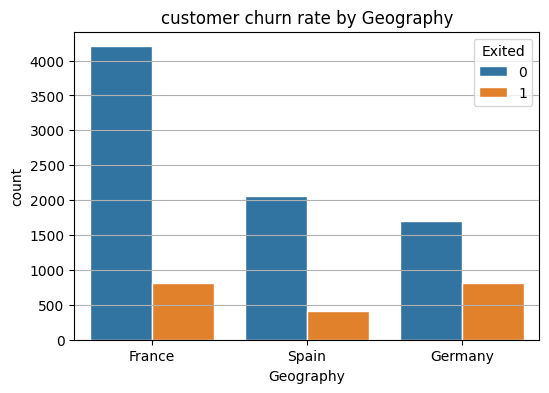

In [23]:
# creating customer churned rate by geography
plt.figure(figsize=(6, 4))
sns.countplot(data = df, x = "Geography",  hue = "Exited", edgecolor="white")
plt.title("customer churn rate by Geography")
plt.grid(axis="y")
plt.show()

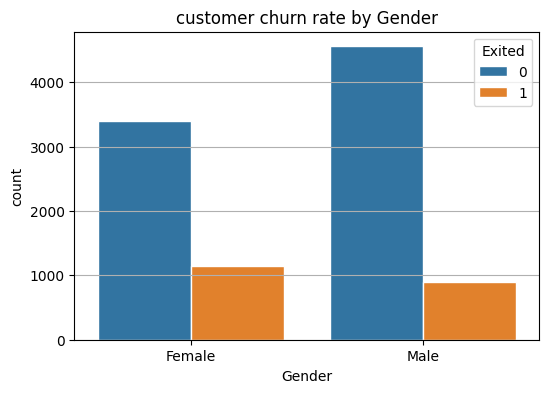

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(data = df, x = "Gender",  hue = "Exited", edgecolor="white")
plt.title("customer churn rate by Gender")
plt.grid(axis="y")
plt.show()

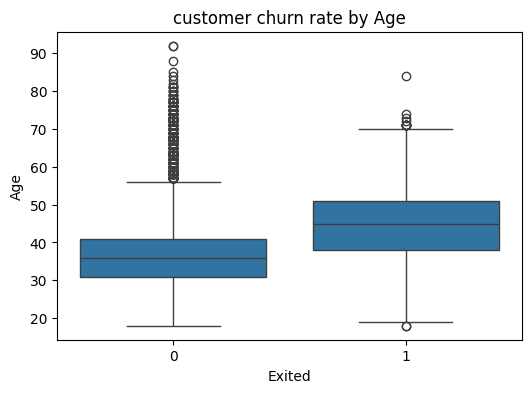

In [25]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Exited",y ="Age")
plt.title("customer churn rate by Age")
# plt.grid(axis="y")
plt.show()

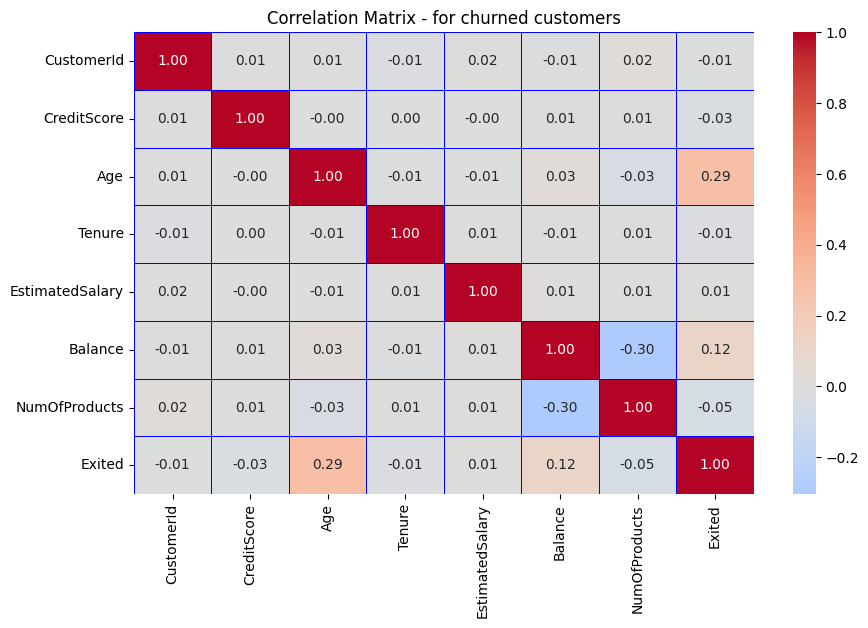

In [26]:
num_cols = df.select_dtypes(include=['float64', 'int64'])
corr = num_cols.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True, fmt=".2f", cmap="coolwarm", center = 0, linewidth="0.5",linecolor= "blue")
plt.title("Correlation Matrix - for churned customers")
plt.show()

In [27]:
num_cols = df[["CreditScore", "Age", "Tenure", "EstimatedSalary", "Balance", "NumOfProducts",]]
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1
lower_bond = Q1 - 1.5 * IQR
upper_bond = Q3 + 1.5* IQR
outliers = ((num_cols < lower_bond) | (num_cols > upper_bond))
outliers.sum()

CreditScore         15
Age                359
Tenure               0
EstimatedSalary      0
Balance              0
NumOfProducts       60
dtype: int64

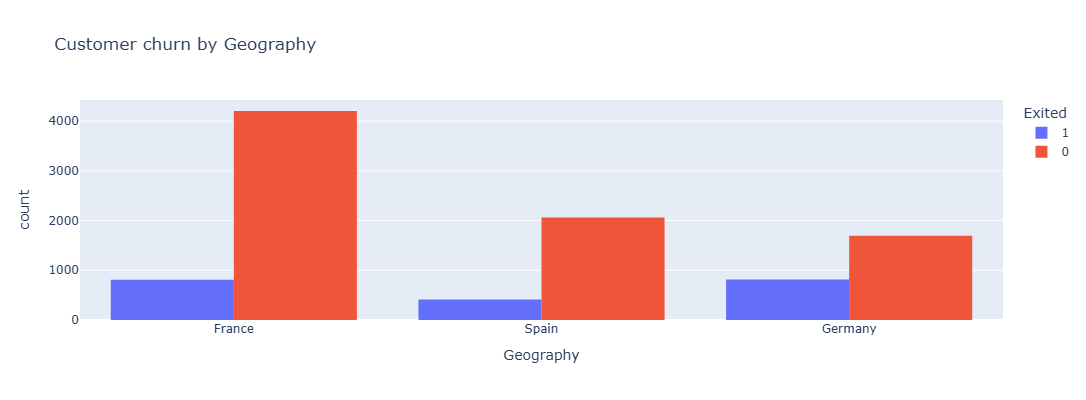

In [28]:
# creating an interactive count plot for customer geography
fig = px.histogram(
    df,
    x="Geography",
    color= "Exited",
    barmode="group",
    
    title="Customer churn by Geography"
)
fig.update_layout(width=600, height= 400)
fig.show()

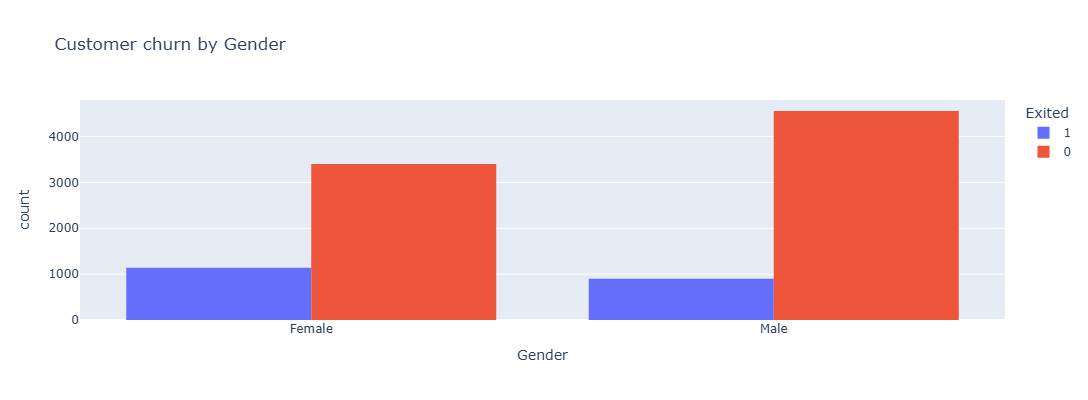

In [29]:
fig = px.histogram(
    df,
    x="Gender",
    color= "Exited",
    barmode="group",
    
    title="Customer churn by Gender"
)
fig.update_layout(width=600, height= 400)
fig.show()

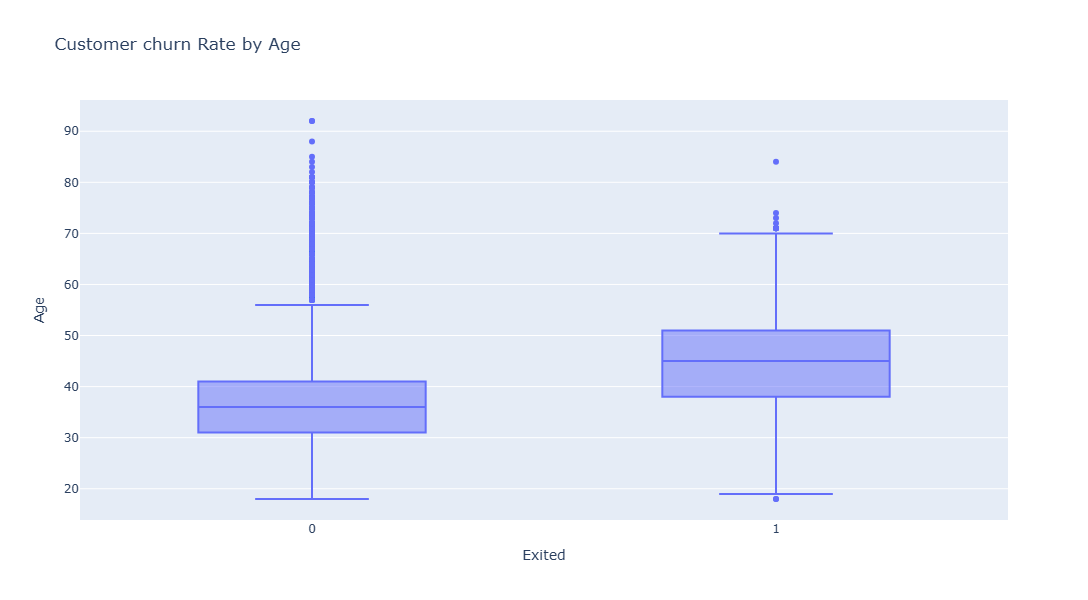

In [30]:
fig = px.box(
    df,
    x="Exited",
    y= "Age",
    title="Customer churn Rate by Age"
)
fig.update_layout(width=800, height= 600)
fig.show()

In [31]:
df.to_csv("cleaned_bank_churned_dataset.csv", index=False)